Install the library

In [ ]:
!pip install ultralytics -q # package which provides YOLOv8/YOLO models

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 575.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00


Verify the environment

In [ ]:
import ultralytics 
ultralytics.checks() #runs a built-in diagnostic that prints the version, Python version, PyTorch version, and available hardware (CPU/GPU), confirming everything is set up correctly

Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.0/107.7 GB disk)


Load a pretrained model

In [ ]:
from ultralytics import YOLO #YOLO class allows to load and use YOLO models for object detection and segmentation tasks.

# Load a pretrained YOLOv8 model (downloads weights automatically on first run)
model = YOLO('yolov8n.pt')

In [ ]:
# Inspect the classes the model was trained to detect (COCO dataset -> 80 classes)
print(f"Number of classes: {len(model.names)}") #a dictionary mapping class IDs (integers) to class name strings
print("First 10 classes:", {k: model.names[k] for k in list(model.names)[:10]})

Number of classes: 80
First 10 classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light'}


Run detection on one image


image 1/1 /content/bus.jpg: 640x384 1 car, 1 bus, 340.3ms
Speed: 16.2ms preprocess, 340.3ms inference, 42.4ms postprocess per image at shape (1, 3, 640, 384)


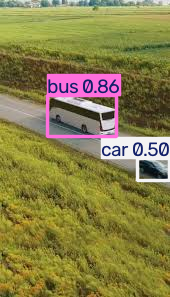

In [ ]:
# Run inference on a single image
results = model('bus.jpg') # runs inference (object detection) on the image and returns a list of result objects

# results is a list (one entry per image). Since we passed one image, take the first result.
result = results[0]

# Display the annotated image inline in the notebook
from IPython.display import display
from PIL import Image
annotated = result.plot()  # draws bounding boxes and labels onto the image, returning it as a NumPy array in BGR color order
display(Image.fromarray(annotated[..., ::-1]))  # displays image after convert BGR -> RGB for correct colors

In [ ]:
# Inspect what was detected: class name, confidence score, bounding box coordinates
print(f"Number of objects detected: {len(result.boxes)}\n") #result.boxes holds all detected bounding boxes 
                                                            #for the image; len(...) counts them.

for box in result.boxes:
    class_id = int(box.cls[0]) #class_id is the integer ID of the detected class (e.g., 0 for "person")
    class_name = model.names[class_id] #class_name is the human-readable name of the detected class (e.g., "person", "bicycle", etc.)
    confidence = float(box.conf[0]) #confidence is the model's confidence score for this detection (between 0 and 1)
    x1, y1, x2, y2 = box.xyxy[0].tolist()  # bounding box corners (pixel coordinates)
    print(f"Class: {class_name:12s} | Confidence: {confidence:.2f} | BBox: ({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")


Number of objects detected: 2

Class: bus          | Confidence: 0.86 | BBox: (48, 95, 116, 137)
Class: car          | Confidence: 0.50 | BBox: (137, 158, 170, 180)


In [ ]:
image_list = ['bus.jpg', 'image1.jpg', 'image2.jpg']

results = model(image_list) # runs inference on a list of images and returns a list of result objects, one for each image

# loops through results while also tracking an index i, used to label each image and match it back to its filename in image_list
for i, res in enumerate(results): 
    print(f"--- Image {i+1}: {image_list[i]} ---")
    print(f"Detected {len(res.boxes)} object(s)")
    for box in res.boxes: #pulls out each detected object's class name and confidence
        class_id = int(box.cls[0])
        print(f"  {model.names[class_id]} (conf={float(box.conf[0]):.2f})")
    print()



0: 640x640 1 car, 1 bus, 225.9ms
1: 640x640 7 persons, 1 car, 1 motorcycle, 2 trucks, 225.9ms
2: 640x640 3 persons, 2 bicycles, 225.9ms
Speed: 4.3ms preprocess, 225.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
--- Image 1: bus.jpg ---
Detected 2 object(s)
  bus (conf=0.86)
  car (conf=0.53)

--- Image 2: image1.jpg ---
Detected 11 object(s)
  truck (conf=0.79)
  truck (conf=0.74)
  car (conf=0.71)
  person (conf=0.70)
  person (conf=0.51)
  motorcycle (conf=0.46)
  person (conf=0.43)
  person (conf=0.38)
  person (conf=0.29)
  person (conf=0.28)
  person (conf=0.26)

--- Image 3: image2.jpg ---
Detected 5 object(s)
  bicycle (conf=0.91)
  bicycle (conf=0.83)
  person (conf=0.75)
  person (conf=0.71)
  person (conf=0.35)



In [10]:
os.makedirs('predictions', exist_ok=True)

for i, res in enumerate(results):
    save_path = f"predictions/result_{i+1}.jpg"
    res.save(filename=save_path)
    print(f"Saved: {save_path}")

Saved: predictions/result_1.jpg
Saved: predictions/result_2.jpg
Saved: predictions/result_3.jpg


In [11]:
results = model(image_list, save=True, project='predictions_auto', name='run1', exist_ok=True)
print("Auto-saved results to the 'predictions_auto/run1' folder")


0: 640x640 1 car, 1 bus, 171.6ms
1: 640x640 7 persons, 1 car, 1 motorcycle, 2 trucks, 171.6ms
2: 640x640 3 persons, 2 bicycles, 171.6ms
Speed: 2.8ms preprocess, 171.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions_auto/run1
Auto-saved results to the 'predictions_auto/run1' folder
